# World Cup Sleep Disruption Data Analysis

**Authors:** [Jaslyn](https://github.com/Jaslyn10) and [Manoj](https://github.com/Manojchandra10)  
**Snapshot:** completed matches through **5 July 2026, 10:18 UTC**

The exact fixture workbook is used for every result. The earlier synthetic kick-off-slot model is retained only as background context and is not used for the final ranking.

### Main assumptions

- Normal sleep window: **23:00–07:00**
- Viewing window: **120 minutes from kick-off**
- A match is counted only after the full viewing window has elapsed
- One representative IANA time zone is used for each fanbase
- Collective interpretation is standardised **per one million supporters**


In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

from pathlib import Path
from datetime import datetime, timedelta, time
from zoneinfo import ZoneInfo
import math
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, PercentFormatter
from scipy.stats import spearmanr, kruskal
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

%matplotlib inline

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (10, 6),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.titleweight": "bold",
    "axes.titlesize": 15,
    "axes.labelsize": 10,
    "font.size": 10,
})

DATA_CANDIDATES = [
    Path.cwd() / "world-cup-2026-schedule.xlsx",
    Path("/mnt/data/world-cup-2026-schedule.xlsx"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Place world-cup-2026-schedule.xlsx in the same folder as this notebook."
    )

SNAPSHOT_UTC = pd.Timestamp("2026-07-05T10:18:00+00:00")
SLEEP_START = time(23, 0)
SLEEP_END = time(7, 0)
MATCH_MINUTES = 120

print("Data sheet:", DATA_PATH)
print("Snapshot:", SNAPSHOT_UTC)


Data sheet: D:\Downloads\world_cup_sleep_updated_project\world-cup-2026-schedule.xlsx
Snapshot: 2026-07-05 10:18:00+00:00


## Configuration and team metadata

In [2]:
RESOLVED_KNOCKOUT_SLOTS = {
    89: ("Canada", "Morocco"),
    90: ("Paraguay", "France"),
    91: ("Brazil", "Norway"),
    92: ("Mexico", "England"),
    93: ("Portugal", "Spain"),
    94: ("United States", "Belgium"),
    95: ("Argentina", "Egypt"),
    96: ("Switzerland", "Colombia"),
    97: ("France", "Morocco"),
}

TEAM_TIMEZONES = {
    "Mexico": ("America/Mexico_City", "Mexico City"),
    "South Africa": ("Africa/Johannesburg", "Johannesburg"),
    "South Korea": ("Asia/Seoul", "Seoul"),
    "Czechia": ("Europe/Prague", "Prague"),
    "Canada": ("America/Toronto", "Toronto"),
    "Bosnia & Herzegovina": ("Europe/Sarajevo", "Sarajevo"),
    "Qatar": ("Asia/Qatar", "Doha"),
    "Switzerland": ("Europe/Zurich", "Zurich"),
    "Brazil": ("America/Sao_Paulo", "São Paulo"),
    "Morocco": ("Africa/Casablanca", "Casablanca"),
    "Haiti": ("America/Port-au-Prince", "Port-au-Prince"),
    "Scotland": ("Europe/London", "Edinburgh"),
    "United States": ("America/New_York", "New York / Eastern Time"),
    "Paraguay": ("America/Asuncion", "Asunción"),
    "Australia": ("Australia/Sydney", "Sydney"),
    "Türkiye": ("Europe/Istanbul", "Istanbul"),
    "Germany": ("Europe/Berlin", "Berlin"),
    "Curaçao": ("America/Curacao", "Willemstad"),
    "Ivory Coast": ("Africa/Abidjan", "Abidjan"),
    "Ecuador": ("America/Guayaquil", "Guayaquil"),
    "Netherlands": ("Europe/Amsterdam", "Amsterdam"),
    "Japan": ("Asia/Tokyo", "Tokyo"),
    "Sweden": ("Europe/Stockholm", "Stockholm"),
    "Tunisia": ("Africa/Tunis", "Tunis"),
    "Belgium": ("Europe/Brussels", "Brussels"),
    "Egypt": ("Africa/Cairo", "Cairo"),
    "Iran": ("Asia/Tehran", "Tehran"),
    "New Zealand": ("Pacific/Auckland", "Auckland"),
    "Spain": ("Europe/Madrid", "Madrid"),
    "Cape Verde": ("Atlantic/Cape_Verde", "Praia"),
    "Saudi Arabia": ("Asia/Riyadh", "Riyadh"),
    "Uruguay": ("America/Montevideo", "Montevideo"),
    "France": ("Europe/Paris", "Paris"),
    "Senegal": ("Africa/Dakar", "Dakar"),
    "Iraq": ("Asia/Baghdad", "Baghdad"),
    "Norway": ("Europe/Oslo", "Oslo"),
    "Argentina": ("America/Argentina/Buenos_Aires", "Buenos Aires"),
    "Algeria": ("Africa/Algiers", "Algiers"),
    "Austria": ("Europe/Vienna", "Vienna"),
    "Jordan": ("Asia/Amman", "Amman"),
    "Portugal": ("Europe/Lisbon", "Lisbon"),
    "DR Congo": ("Africa/Kinshasa", "Kinshasa"),
    "Uzbekistan": ("Asia/Tashkent", "Tashkent"),
    "Colombia": ("America/Bogota", "Bogotá"),
    "England": ("Europe/London", "London"),
    "Croatia": ("Europe/Zagreb", "Zagreb"),
    "Ghana": ("Africa/Accra", "Accra"),
    "Panama": ("America/Panama", "Panama City"),
}

REGIONS = {
    "Mexico": "North America",
    "South Africa": "Africa",
    "South Korea": "Asia",
    "Czechia": "Europe",
    "Canada": "North America",
    "Bosnia & Herzegovina": "Europe",
    "Qatar": "Asia",
    "Switzerland": "Europe",
    "Brazil": "South America",
    "Morocco": "Africa",
    "Haiti": "Caribbean",
    "Scotland": "Europe",
    "United States": "North America",
    "Paraguay": "South America",
    "Australia": "Oceania",
    "Türkiye": "Europe",
    "Germany": "Europe",
    "Curaçao": "Caribbean",
    "Ivory Coast": "Africa",
    "Ecuador": "South America",
    "Netherlands": "Europe",
    "Japan": "Asia",
    "Sweden": "Europe",
    "Tunisia": "Africa",
    "Belgium": "Europe",
    "Egypt": "Africa",
    "Iran": "Asia",
    "New Zealand": "Oceania",
    "Spain": "Europe",
    "Cape Verde": "Africa",
    "Saudi Arabia": "Asia",
    "Uruguay": "South America",
    "France": "Europe",
    "Senegal": "Africa",
    "Iraq": "Asia",
    "Norway": "Europe",
    "Argentina": "South America",
    "Algeria": "Africa",
    "Austria": "Europe",
    "Jordan": "Asia",
    "Portugal": "Europe",
    "DR Congo": "Africa",
    "Uzbekistan": "Asia",
    "Colombia": "South America",
    "England": "Europe",
    "Croatia": "Europe",
    "Ghana": "Africa",
    "Panama": "Central America",
}

groups_raw = pd.read_excel(DATA_PATH, sheet_name="Groups Overview", header=None)

team_metadata_rows = []
current_group = None

for _, row in groups_raw.iterrows():
    first_value = str(row.iloc[0]) if pd.notna(row.iloc[0]) else ""
    if first_value.startswith("Group "):
        current_group = first_value
    elif pd.notna(row.iloc[1]) and pd.notna(row.iloc[3]):
        fanbase = str(row.iloc[1]).strip()
        team_metadata_rows.append({
            "fanbase": fanbase,
            "group": current_group,
            "confederation": str(row.iloc[3]).strip(),
            "region": REGIONS[fanbase],
        })

team_metadata = pd.DataFrame(team_metadata_rows)

assert len(team_metadata) == 48
assert team_metadata["fanbase"].is_unique
assert set(team_metadata["fanbase"]) == set(TEAM_TIMEZONES)

display(team_metadata.head(12))


,fanbase,group,confederation,region
0,Mexico,Group A,CONCACAF,North America
1,South Africa,Group A,CAF,Africa
2,South Korea,Group A,AFC,Asia
3,Czechia,Group A,UEFA,Europe
4,Canada,Group B,CONCACAF,North America
5,Qatar,Group B,AFC,Asia
6,Switzerland,Group B,UEFA,Europe
7,Bosnia & Herzegovina,Group B,UEFA,Europe
8,Brazil,Group C,CONMEBOL,South America
9,Morocco,Group C,CAF,Africa


## Load, inspect and clean the fixture workbook


In [3]:
workbook = pd.ExcelFile(DATA_PATH)
sheet_overview = pd.DataFrame({
    "sheet": workbook.sheet_names,
    "rows": [pd.read_excel(DATA_PATH, sheet_name=sheet).shape[0] for sheet in workbook.sheet_names],
    "columns": [pd.read_excel(DATA_PATH, sheet_name=sheet).shape[1] for sheet in workbook.sheet_names],
})

raw = pd.read_excel(DATA_PATH, sheet_name="Full Schedule", engine="openpyxl")

column_profile = pd.DataFrame({
    "column": raw.columns,
    "dtype": [str(raw[column].dtype) for column in raw.columns],
    "non_null": [int(raw[column].notna().sum()) for column in raw.columns],
    "missing": [int(raw[column].isna().sum()) for column in raw.columns],
    "missing_pct": [float(raw[column].isna().mean()) for column in raw.columns],
    "unique": [int(raw[column].nunique(dropna=True)) for column in raw.columns],
})

duplicate_full_rows = int(raw.duplicated().sum())
duplicate_match_numbers = int(
    raw.loc[raw["Match #"].notna(), "Match #"].duplicated().sum()
)

display(sheet_overview)
display(column_profile)
print("Duplicate full rows:", duplicate_full_rows)
print("Duplicate match numbers:", duplicate_match_numbers)
display(raw.head())


,sheet,rows,columns
0,Full Schedule,106,10
1,Group Stage,86,10
2,Knockout Stage,40,10
3,Groups Overview,73,4
4,Venues,18,5


,column,dtype,non_null,missing,missing_pct,unique
0,Match #,object,105,1,0.009,105
1,Date,object,104,2,0.019,35
2,Kickoff (UTC),object,104,2,0.019,17
3,Kickoff (ET),object,104,2,0.019,17
4,Team A,object,104,2,0.019,49
5,Team B,object,104,2,0.019,49
6,Group / Round,object,104,2,0.019,18
7,Venue,object,104,2,0.019,16
8,City,object,104,2,0.019,16
9,Host Country,object,104,2,0.019,3


Duplicate full rows: 0
Duplicate match numbers: 0


,Match #,Date,Kickoff (UTC),Kickoff (ET),Team A,Team B,Group / Round,Venue,City,Host Country
0,1,"Jun 11, 2026",19:00,3:00 PM,Mexico,South Africa,Group A,Estadio Azteca,Mexico City,Mexico
1,2,"Jun 12, 2026",02:00,10:00 PM,South Korea,Czechia,Group A,Estadio Akron,Guadalajara,Mexico
2,3,"Jun 12, 2026",19:00,3:00 PM,Canada,Bosnia & Herzegovina,Group B,BMO Field,Toronto,Canada
3,4,"Jun 13, 2026",01:00,9:00 PM,United States,Paraguay,Group D,SoFi Stadium,Inglewood,USA
4,5,"Jun 13, 2026",19:00,3:00 PM,Qatar,Switzerland,Group B,Levi's Stadium,Santa Clara,USA


In [4]:
def parse_kickoff_utc(date_value, time_value):
    date_text = pd.to_datetime(str(date_value), errors="coerce")
    if pd.isna(date_text):
        raise ValueError(f"Bad date: {date_value!r}")

    if isinstance(time_value, time):
        time_text = time_value.strftime("%H:%M")
    elif isinstance(time_value, datetime):
        time_text = time_value.strftime("%H:%M")
    else:
        time_text = str(time_value).strip()
        if re.fullmatch(r"\d{1,2}:\d{2}:\d{2}", time_text):
            time_text = time_text[:5]

    combined = pd.to_datetime(
        f"{date_text.date().isoformat()} {time_text}",
        errors="coerce",
        utc=True,
    )
    if pd.isna(combined):
        raise ValueError(f"Bad date/time pair: {date_value!r}, {time_value!r}")
    return combined


schedule = raw.copy()
schedule.columns = [str(column).strip() for column in schedule.columns]
schedule = schedule[schedule["Match #"].notna()].copy()
schedule["Match #"] = pd.to_numeric(schedule["Match #"], errors="coerce")
schedule = schedule[schedule["Match #"].notna()].copy()
schedule["Match #"] = schedule["Match #"].astype(int)

text_columns = [
    "Team A", "Team B", "Group / Round", "Venue", "City", "Host Country"
]
for column in text_columns:
    schedule[column] = schedule[column].astype("string").str.strip()

schedule["kickoff_utc"] = [
    parse_kickoff_utc(date_value, time_value)
    for date_value, time_value in zip(schedule["Date"], schedule["Kickoff (UTC)"])
]

for match_number, teams in RESOLVED_KNOCKOUT_SLOTS.items():
    schedule.loc[
        schedule["Match #"].eq(match_number),
        ["Team A", "Team B"],
    ] = teams

schedule["stage_type"] = np.select(
    [
        schedule["Group / Round"].str.contains("Group", case=False, na=False),
        schedule["Group / Round"].str.contains("Round of 32", case=False, na=False),
        schedule["Group / Round"].str.contains("Round of 16", case=False, na=False),
        schedule["Group / Round"].str.contains("Quarter", case=False, na=False),
        schedule["Group / Round"].str.contains("Semi", case=False, na=False),
        schedule["Group / Round"].str.contains("Third", case=False, na=False),
        schedule["Group / Round"].str.fullmatch("Final", case=False, na=False),
    ],
    [
        "Group stage",
        "Round of 32",
        "Round of 16",
        "Quarter-final",
        "Semi-final",
        "Third place",
        "Final",
    ],
    default=schedule["Group / Round"].fillna("Other"),
)

schedule["scheduled_end_utc"] = (
    schedule["kickoff_utc"] + pd.Timedelta(minutes=MATCH_MINUTES)
)
schedule["snapshot_status"] = np.where(
    schedule["scheduled_end_utc"].le(SNAPSHOT_UTC),
    "Completed",
    "Upcoming",
)

schedule = schedule.sort_values(["kickoff_utc", "Match #"]).reset_index(drop=True)

expected_matches = set(range(1, 105))
actual_matches = set(schedule["Match #"])

assert len(schedule) == 104
assert schedule["Match #"].is_unique
assert actual_matches == expected_matches
assert schedule["kickoff_utc"].notna().all()
assert schedule["Venue"].notna().all()
assert schedule["City"].notna().all()

validation = pd.DataFrame({
    "check": [
        "Clean match rows",
        "Unique match numbers",
        "Match-number coverage",
        "Completed matches at snapshot",
        "Upcoming matches at snapshot",
        "Known fanbases",
    ],
    "value": [
        len(schedule),
        schedule["Match #"].nunique(),
        "1–104",
        int(schedule["snapshot_status"].eq("Completed").sum()),
        int(schedule["snapshot_status"].eq("Upcoming").sum()),
        len(TEAM_TIMEZONES),
    ],
})

display(validation)
display(schedule.head())


,check,value
0,Clean match rows,104
1,Unique match numbers,104
2,Match-number coverage,1–104
3,Completed matches at snapshot,90
4,Upcoming matches at snapshot,14
5,Known fanbases,48


,Match #,Date,Kickoff (UTC),Kickoff (ET),Team A,Team B,Group / Round,Venue,City,Host Country,kickoff_utc,stage_type,scheduled_end_utc,snapshot_status
0,1,"Jun 11, 2026",19:00,3:00 PM,Mexico,South Africa,Group A,Estadio Azteca,Mexico City,Mexico,2026-06-11 19:00:00+00:00,Group stage,2026-06-11 21:00:00+00:00,Completed
1,2,"Jun 12, 2026",02:00,10:00 PM,South Korea,Czechia,Group A,Estadio Akron,Guadalajara,Mexico,2026-06-12 02:00:00+00:00,Group stage,2026-06-12 04:00:00+00:00,Completed
2,3,"Jun 12, 2026",19:00,3:00 PM,Canada,Bosnia & Herzegovina,Group B,BMO Field,Toronto,Canada,2026-06-12 19:00:00+00:00,Group stage,2026-06-12 21:00:00+00:00,Completed
3,4,"Jun 13, 2026",01:00,9:00 PM,United States,Paraguay,Group D,SoFi Stadium,Inglewood,USA,2026-06-13 01:00:00+00:00,Group stage,2026-06-13 03:00:00+00:00,Completed
4,5,"Jun 13, 2026",19:00,3:00 PM,Qatar,Switzerland,Group B,Levi's Stadium,Santa Clara,USA,2026-06-13 19:00:00+00:00,Group stage,2026-06-13 21:00:00+00:00,Completed


## Tournament schedule exploration


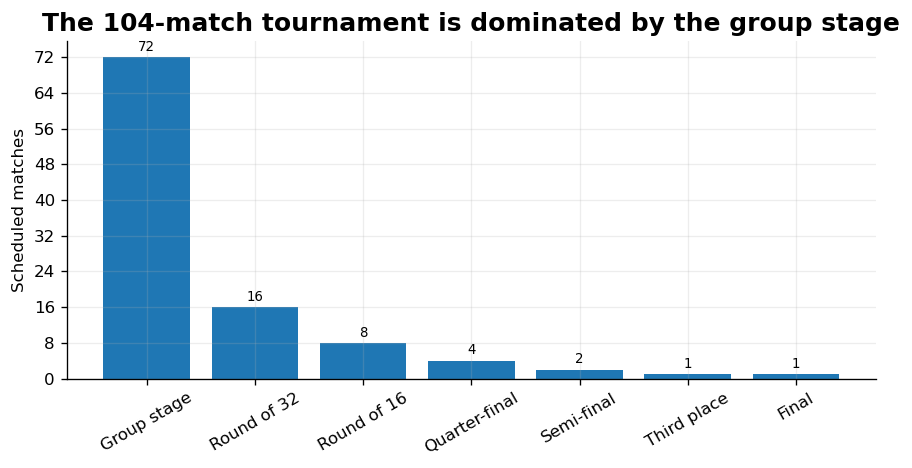

In [5]:
stage_order = [
    "Group stage",
    "Round of 32",
    "Round of 16",
    "Quarter-final",
    "Semi-final",
    "Third place",
    "Final",
]

stage_counts = (
    schedule.groupby("stage_type", as_index=False)
    .agg(matches=("Match #", "count"))
    .assign(
        stage_type=lambda frame: pd.Categorical(
            frame["stage_type"], categories=stage_order, ordered=True
        )
    )
    .sort_values("stage_type")
)

fig, ax = plt.subplots(figsize=(7.5, 4))
bars = ax.bar(stage_counts["stage_type"].astype(str), stage_counts["matches"])
ax.bar_label(bars, padding=2, fontsize=8)
ax.set_title("The 104-match tournament is dominated by the group stage")
ax.set_xlabel("")
ax.set_ylabel("Scheduled matches")
ax.tick_params(axis="x", rotation=30)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()


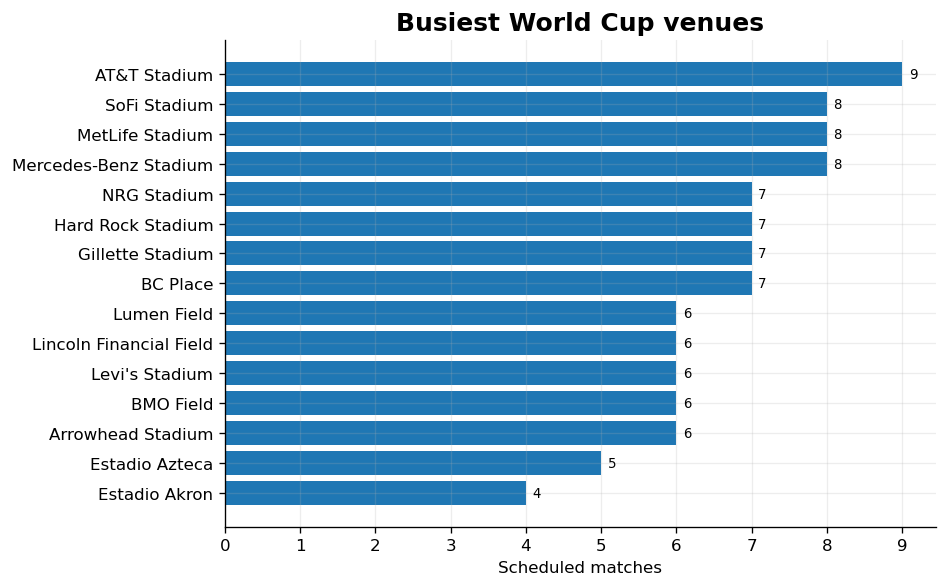

In [6]:
venue_counts = (
    schedule.groupby(["Host Country", "City", "Venue"], as_index=False)
    .agg(matches=("Match #", "count"))
    .sort_values(["matches", "Venue"], ascending=[False, True])
    .head(15)
    .sort_values("matches")
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(venue_counts["Venue"], venue_counts["matches"])
ax.bar_label(bars, padding=4, fontsize=8)
ax.set_title("Busiest World Cup venues")
ax.set_xlabel("Scheduled matches")
ax.set_ylabel("")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()


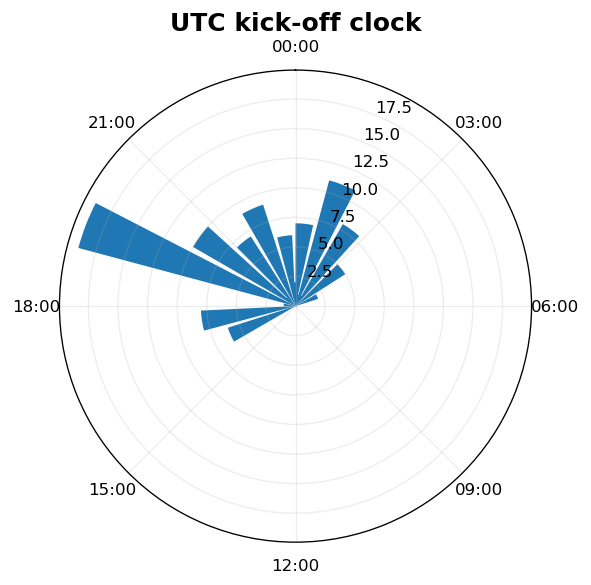

In [7]:
utc_hour_counts = (
    schedule.assign(
        utc_hour=schedule["kickoff_utc"].dt.hour
        + schedule["kickoff_utc"].dt.minute / 60
    )
    .groupby("utc_hour", as_index=False)
    .agg(matches=("Match #", "count"))
    .sort_values("utc_hour")
)

theta = 2 * np.pi * utc_hour_counts["utc_hour"] / 24
width = 2 * np.pi / 24 * 0.82

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection="polar")
ax.bar(theta, utc_hour_counts["matches"], width=width, align="edge")
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_xticks(2 * np.pi * np.arange(0, 24, 3) / 24)
ax.set_xticklabels([f"{hour:02d}:00" for hour in range(0, 24, 3)])
ax.set_title("UTC kick-off clock", pad=24)
plt.tight_layout()
plt.show()


## Sleep-window model and fanbase-match records

Each fixture is converted from UTC into the representative home time zone of both fanbases. The overlap between the 120-minute viewing window and the 23:00-07:00 sleep window is measured exactly, including matches that cross midnight.


In [8]:
def sleep_overlap_hours(
    local_start,
    sleep_start=SLEEP_START,
    sleep_end=SLEEP_END,
    match_minutes=MATCH_MINUTES,
):
    local_end = local_start + pd.Timedelta(minutes=match_minutes)
    total = pd.Timedelta(0)

    current_date = local_start.date() - timedelta(days=1)
    final_date = local_end.date()

    while current_date <= final_date:
        window_start = pd.Timestamp(
            datetime.combine(current_date, sleep_start),
            tz=local_start.tz,
        )
        end_date = (
            current_date + timedelta(days=1)
            if sleep_end <= sleep_start
            else current_date
        )
        window_end = pd.Timestamp(
            datetime.combine(end_date, sleep_end),
            tz=local_start.tz,
        )

        overlap_start = max(local_start, window_start)
        overlap_end = min(local_end, window_end)

        if overlap_end > overlap_start:
            total += overlap_end - overlap_start

        current_date += timedelta(days=1)

    return round(total.total_seconds() / 3600, 4)


completed = schedule[
    schedule["scheduled_end_utc"].le(SNAPSHOT_UTC)
    & schedule["Team A"].ne("TBD")
    & schedule["Team B"].ne("TBD")
].copy()

unknown_teams = sorted(
    (set(completed["Team A"]) | set(completed["Team B"]))
    - set(TEAM_TIMEZONES)
)
assert not unknown_teams, f"Missing time zones: {unknown_teams}"

records = []

for _, match in completed.iterrows():
    for fanbase, opponent in (
        (match["Team A"], match["Team B"]),
        (match["Team B"], match["Team A"]),
    ):
        zone_name, representative_city = TEAM_TIMEZONES[fanbase]
        local_start = match["kickoff_utc"].tz_convert(ZoneInfo(zone_name))
        local_end = local_start + pd.Timedelta(minutes=MATCH_MINUTES)
        overlap = sleep_overlap_hours(local_start)

        records.append({
            "fanbase": fanbase,
            "opponent": opponent,
            "match_number": int(match["Match #"]),
            "stage": match["stage_type"],
            "group_or_round": match["Group / Round"],
            "kickoff_utc": match["kickoff_utc"],
            "local_kickoff": local_start,
            "local_end": local_end,
            "local_hour": local_start.hour + local_start.minute / 60,
            "local_hour_int": local_start.hour,
            "local_weekday": local_start.day_name(),
            "local_date": local_start.date().isoformat(),
            "sleep_overlap_hours": overlap,
            "sleep_affected": overlap > 0,
            "timezone": zone_name,
            "representative_city": representative_city,
            "utc_offset_hours": local_start.utcoffset().total_seconds() / 3600,
            "venue": match["Venue"],
            "host_city": match["City"],
            "host_country": match["Host Country"],
        })

team_matches = (
    pd.DataFrame(records)
    .sort_values(["fanbase", "kickoff_utc", "match_number"])
    .reset_index(drop=True)
)

assert len(team_matches) == 2 * completed["Match #"].nunique()
assert team_matches["sleep_overlap_hours"].between(0, MATCH_MINUTES / 60).all()
assert team_matches["fanbase"].nunique() == 48

display(team_matches.head(12))


,fanbase,opponent,match_number,stage,group_or_round,kickoff_utc,local_kickoff,local_end,local_hour,local_hour_int,local_weekday,local_date,sleep_overlap_hours,sleep_affected,timezone,representative_city,utc_offset_hours,venue,host_city,host_country
0,Algeria,Argentina,19,Group stage,Group J,2026-06-17 01:00:00+00:00,2026-06-17 02:00:00+01:00,2026-06-17 04:00:00+01:00,2.000,2,Wednesday,2026-06-17,2.000,True,Africa/Algiers,Algiers,1.000,Arrowhead Stadium,Kansas City,USA
1,Algeria,Jordan,44,Group stage,Group J,2026-06-23 03:00:00+00:00,2026-06-23 04:00:00+01:00,2026-06-23 06:00:00+01:00,4.000,4,Tuesday,2026-06-23,2.000,True,Africa/Algiers,Algiers,1.000,Levi's Stadium,Santa Clara,USA
2,Algeria,Austria,71,Group stage,Group J,2026-06-28 02:00:00+00:00,2026-06-28 03:00:00+01:00,2026-06-28 05:00:00+01:00,3.000,3,Sunday,2026-06-28,2.000,True,Africa/Algiers,Algiers,1.000,Arrowhead Stadium,Kansas City,USA
3,Algeria,Switzerland,85,Round of 32,Round of 32,2026-07-03 03:00:00+00:00,2026-07-03 04:00:00+01:00,2026-07-03 06:00:00+01:00,4.000,4,Friday,2026-07-03,2.000,True,Africa/Algiers,Algiers,1.000,BC Place,Vancouver,Canada
4,Argentina,Algeria,19,Group stage,Group J,2026-06-17 01:00:00+00:00,2026-06-16 22:00:00-03:00,2026-06-17 00:00:00-03:00,22.000,22,Tuesday,2026-06-16,1.000,True,America/Argentina/Buenos_Aires,Buenos Aires,-3.000,Arrowhead Stadium,Kansas City,USA
5,Argentina,Austria,41,Group stage,Group J,2026-06-22 17:00:00+00:00,2026-06-22 14:00:00-03:00,2026-06-22 16:00:00-03:00,14.000,14,Monday,2026-06-22,0.000,False,America/Argentina/Buenos_Aires,Buenos Aires,-3.000,AT&T Stadium,Arlington,USA
6,Argentina,Jordan,72,Group stage,Group J,2026-06-28 02:00:00+00:00,2026-06-27 23:00:00-03:00,2026-06-28 01:00:00-03:00,23.000,23,Saturday,2026-06-27,2.000,True,America/Argentina/Buenos_Aires,Buenos Aires,-3.000,AT&T Stadium,Arlington,USA
7,Argentina,Cape Verde,87,Round of 32,Round of 32,2026-07-03 22:00:00+00:00,2026-07-03 19:00:00-03:00,2026-07-03 21:00:00-03:00,19.000,19,Friday,2026-07-03,0.000,False,America/Argentina/Buenos_Aires,Buenos Aires,-3.000,Hard Rock Stadium,Miami Gardens,USA
8,Australia,Türkiye,8,Group stage,Group D,2026-06-14 16:00:00+00:00,2026-06-15 02:00:00+10:00,2026-06-15 04:00:00+10:00,2.000,2,Monday,2026-06-15,2.000,True,Australia/Sydney,Sydney,10.000,BC Place,Vancouver,Canada
9,Australia,United States,29,Group stage,Group D,2026-06-19 19:00:00+00:00,2026-06-20 05:00:00+10:00,2026-06-20 07:00:00+10:00,5.000,5,Saturday,2026-06-20,2.000,True,Australia/Sydney,Sydney,10.000,Lumen Field,Seattle,USA


In [9]:
sleep_model_summary = pd.DataFrame({
    "metric": [
        "Completed matches counted",
        "Fanbase-match observations",
        "Fanbases represented",
        "Total sleep overlap across all fanbase views",
        "Affected fanbase-match observations",
        "Share of fanbase views affected",
    ],
    "value": [
        completed["Match #"].nunique(),
        len(team_matches),
        team_matches["fanbase"].nunique(),
        f"{team_matches['sleep_overlap_hours'].sum():,.1f} hours",
        int(team_matches["sleep_affected"].sum()),
        f"{team_matches['sleep_affected'].mean():.1%}",
    ],
})

display(sleep_model_summary)


,metric,value
0,Completed matches counted,90
1,Fanbase-match observations,180
2,Fanbases represented,48
3,Total sleep overlap across all fanbase views,146.0 hours
4,Affected fanbase-match observations,84
5,Share of fanbase views affected,46.7%


## Final fanbase ranking and burden structure


In [10]:
def longest_true_streak(values):
    longest = 0
    current = 0
    for value in values:
        current = current + 1 if bool(value) else 0
        longest = max(longest, current)
    return longest


streak_rows = []
for fanbase, group in team_matches.sort_values("kickoff_utc").groupby("fanbase"):
    streak_rows.append({
        "fanbase": fanbase,
        "longest_affected_streak": longest_true_streak(group["sleep_affected"]),
        "sleep_hours_sd": group["sleep_overlap_hours"].std(ddof=0),
    })
streaks = pd.DataFrame(streak_rows)

stage_burden = (
    team_matches.groupby(["fanbase", "stage"], as_index=False)
    .agg(stage_sleep_hours=("sleep_overlap_hours", "sum"))
)
dominant_stage = (
    stage_burden.sort_values(
        ["fanbase", "stage_sleep_hours", "stage"],
        ascending=[True, False, True],
    )
    .drop_duplicates("fanbase")
    .rename(columns={
        "stage": "dominant_stage",
        "stage_sleep_hours": "dominant_stage_hours",
    })
)

rankings = (
    team_matches.groupby(
        ["fanbase", "timezone", "representative_city"],
        as_index=False,
        observed=True,
    )
    .agg(
        matches_counted=("match_number", "nunique"),
        sleep_affected_matches=("sleep_affected", "sum"),
        total_sleep_hours=("sleep_overlap_hours", "sum"),
        mean_sleep_hours_per_match=("sleep_overlap_hours", "mean"),
        median_sleep_hours_per_match=("sleep_overlap_hours", "median"),
        max_single_match_sleep_hours=("sleep_overlap_hours", "max"),
        earliest_local_hour=("local_hour", "min"),
        latest_local_hour=("local_hour", "max"),
        mean_utc_offset_hours=("utc_offset_hours", "mean"),
    )
    .merge(team_metadata, on="fanbase", how="left")
    .merge(streaks, on="fanbase", how="left")
    .merge(
        dominant_stage[
            ["fanbase", "dominant_stage", "dominant_stage_hours"]
        ],
        on="fanbase",
        how="left",
    )
)

rankings["sleep_affected_share"] = (
    rankings["sleep_affected_matches"] / rankings["matches_counted"]
)
rankings["night_equivalents"] = rankings["total_sleep_hours"] / 8
rankings["hours_per_million_supporters"] = (
    rankings["total_sleep_hours"] * 1_000_000
)
rankings["years_per_million_supporters"] = (
    rankings["hours_per_million_supporters"] / (24 * 365)
)
rankings["largest_match_share"] = np.where(
    rankings["total_sleep_hours"] > 0,
    rankings["max_single_match_sleep_hours"]
    / rankings["total_sleep_hours"],
    0,
)

rankings = rankings.sort_values(
    [
        "total_sleep_hours",
        "sleep_affected_share",
        "sleep_affected_matches",
        "fanbase",
    ],
    ascending=[False, False, False, True],
).reset_index(drop=True)

rankings.insert(0, "rank", np.arange(1, len(rankings) + 1))

ranking_columns = [
    "rank",
    "fanbase",
    "confederation",
    "region",
    "matches_counted",
    "sleep_affected_matches",
    "sleep_affected_share",
    "total_sleep_hours",
    "mean_sleep_hours_per_match",
    "max_single_match_sleep_hours",
    "longest_affected_streak",
    "dominant_stage",
    "years_per_million_supporters",
]

display(rankings[ranking_columns])


,rank,fanbase,confederation,region,matches_counted,sleep_affected_matches,sleep_affected_share,total_sleep_hours,mean_sleep_hours_per_match,max_single_match_sleep_hours,longest_affected_streak,dominant_stage,years_per_million_supporters
0,1,Algeria,CAF,Africa,4,4,1.000,8.000,2.000,2.000,4,Group stage,913.242
1,2,Morocco,CAF,Africa,5,4,0.800,8.000,1.600,2.000,4,Group stage,913.242
2,3,Croatia,UEFA,Europe,4,4,1.000,7.000,1.750,2.000,4,Group stage,799.087
3,4,Scotland,UEFA,Europe,3,3,1.000,6.000,2.000,2.000,3,Group stage,684.932
4,5,Tunisia,CAF,Africa,3,3,1.000,6.000,2.000,2.000,3,Group stage,684.932
5,6,Australia,AFC,Oceania,4,3,0.750,6.000,1.500,2.000,2,Group stage,684.932
6,7,Sweden,UEFA,Europe,4,3,0.750,6.000,1.500,2.000,2,Group stage,684.932
7,8,France,UEFA,Europe,5,3,0.600,6.000,1.200,2.000,2,Group stage,684.932
8,9,Iraq,AFC,Asia,3,3,1.000,5.000,1.667,2.000,3,Group stage,570.776
9,10,Netherlands,UEFA,Europe,4,3,0.750,5.000,1.250,2.000,2,Group stage,570.776


In [11]:
top_fanbase = rankings.iloc[0]
zero_fanbases = rankings.loc[
    rankings["total_sleep_hours"].eq(0), "fanbase"
].tolist()

display(Markdown(f'''
### Ranking snapshot

- **{top_fanbase["fanbase"]}** ranks first with **{top_fanbase["total_sleep_hours"]:.1f} hours** lost per supporter.
- That equals **{top_fanbase["years_per_million_supporters"]:,.0f} years** for every one million supporters.
- The mean is **{rankings["total_sleep_hours"].mean():.2f} hours** and the median is **{rankings["total_sleep_hours"].median():.2f} hours**.
- **{len(zero_fanbases)} fanbases** have no overlap under the baseline assumptions: {", ".join(zero_fanbases)}.
'''))



### Ranking snapshot

- **Algeria** ranks first with **8.0 hours** lost per supporter.
- That equals **913 years** for every one million supporters.
- The mean is **3.04 hours** and the median is **3.00 hours**.
- **10 fanbases** have no overlap under the baseline assumptions: Canada, Colombia, Curaçao, Ecuador, Haiti, Mexico, New Zealand, Panama, South Korea, Uruguay.


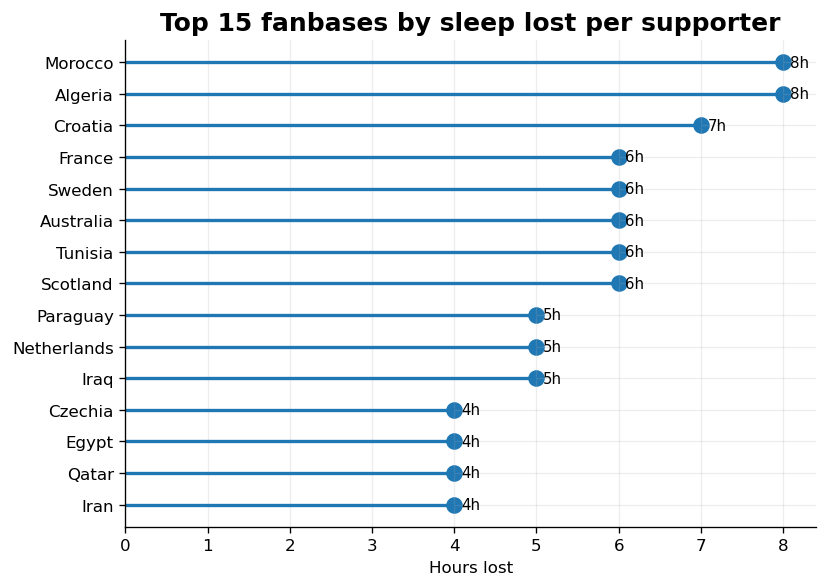

In [12]:
top_15 = rankings.head(15).sort_values("total_sleep_hours")
y = np.arange(len(top_15))

fig, ax = plt.subplots(figsize=(7, 5))
ax.hlines(y, 0, top_15["total_sleep_hours"], linewidth=2)
ax.scatter(top_15["total_sleep_hours"], y, s=80)
ax.set_yticks(y)
ax.set_yticklabels(top_15["fanbase"])
ax.set_title("Top 15 fanbases by sleep lost per supporter")
ax.set_xlabel("Hours lost")
ax.set_ylabel("")
ax.set_xlim(left=0)

for index, value in enumerate(top_15["total_sleep_hours"]):
    ax.text(value + 0.08, index, f"{value:g}h", va="center", fontsize=9)

plt.tight_layout()
plt.show()


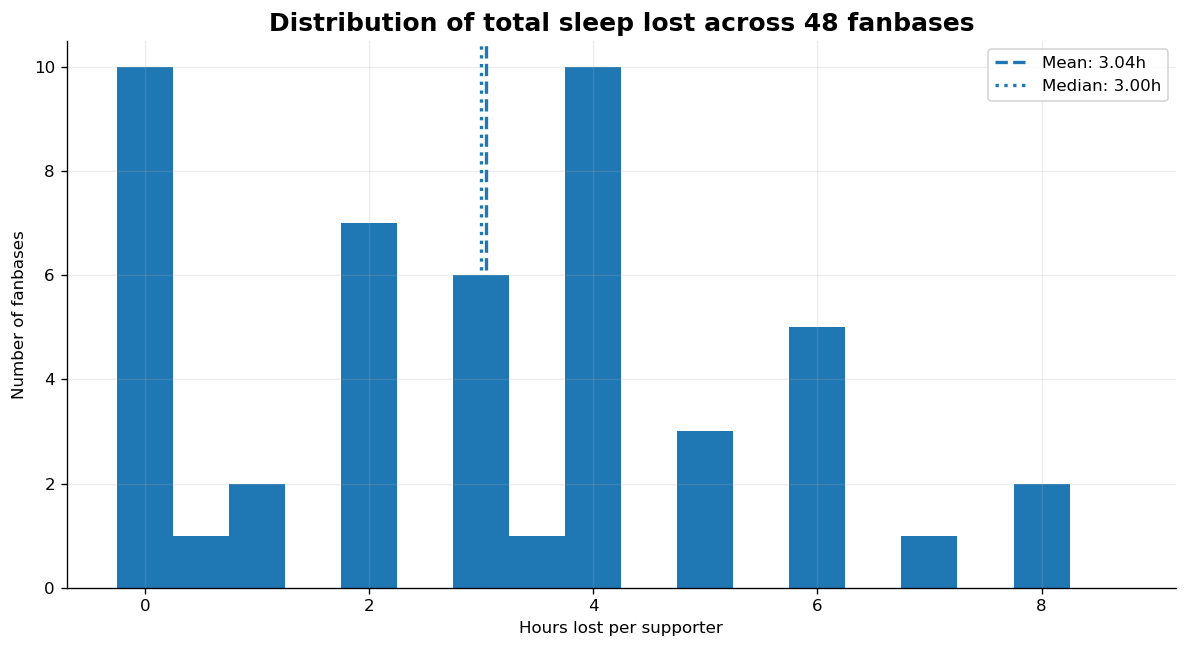

In [13]:
values = rankings["total_sleep_hours"]

fig, ax = plt.subplots(figsize=(10, 5.5))
bins = np.arange(-0.25, values.max() + 0.76, 0.5)
ax.hist(values, bins=bins)
ax.axvline(values.mean(), linestyle="--", linewidth=2, label=f"Mean: {values.mean():.2f}h")
ax.axvline(values.median(), linestyle=":", linewidth=2, label=f"Median: {values.median():.2f}h")
ax.set_title("Distribution of total sleep lost across 48 fanbases")
ax.set_xlabel("Hours lost per supporter")
ax.set_ylabel("Number of fanbases")
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend()
plt.tight_layout()
plt.show()


## Geography, confederations and time zones


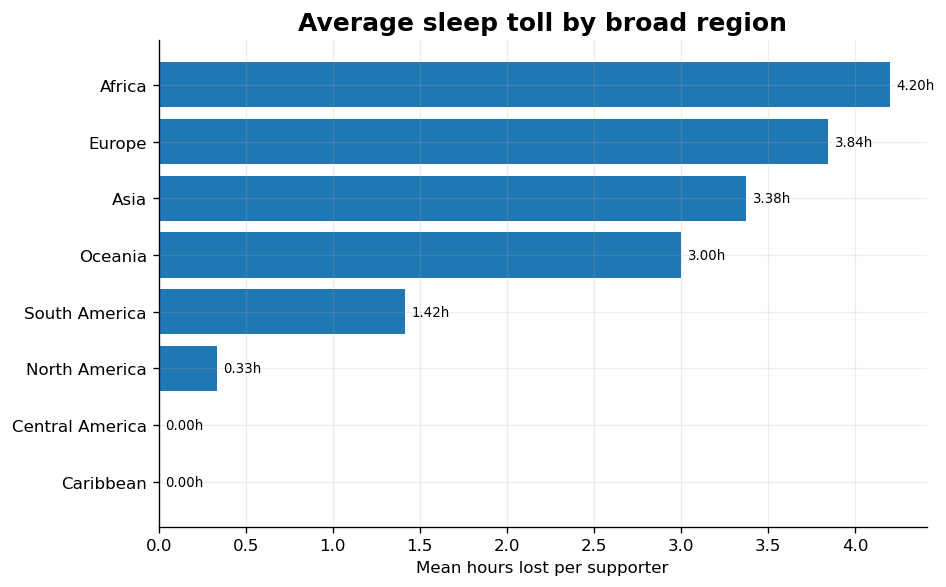

,region,fanbases,mean_sleep_hours,median_sleep_hours,affected_share
0,Africa,10,4.200,4.000,0.555
4,Europe,16,3.844,3.750,0.574
1,Asia,8,3.375,4.000,0.688
6,Oceania,2,3.000,3.000,0.375
7,South America,6,1.417,0.250,0.225
5,North America,3,0.333,0.000,0.083
2,Caribbean,2,0.000,0.000,0.000
3,Central America,1,0.000,0.000,0.000


In [14]:
region_summary = (
    rankings.groupby("region", as_index=False)
    .agg(
        fanbases=("fanbase", "count"),
        mean_sleep_hours=("total_sleep_hours", "mean"),
        median_sleep_hours=("total_sleep_hours", "median"),
        affected_share=("sleep_affected_share", "mean"),
    )
    .sort_values("mean_sleep_hours")
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(region_summary["region"], region_summary["mean_sleep_hours"])
ax.bar_label(bars, fmt="%.2fh", padding=4, fontsize=8)
ax.set_title("Average sleep toll by broad region")
ax.set_xlabel("Mean hours lost per supporter")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

display(region_summary.sort_values("mean_sleep_hours", ascending=False))


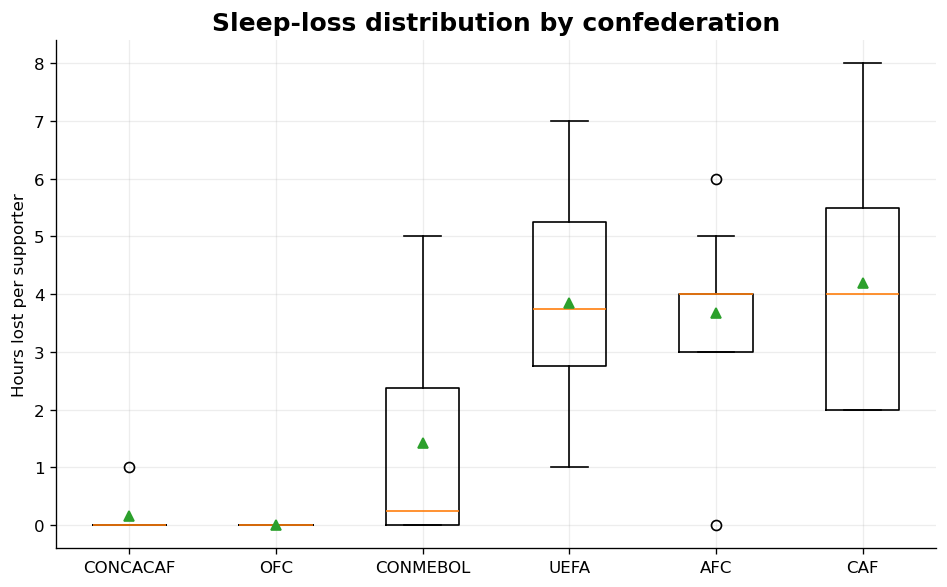

Kruskal–Wallis H = 17.911
p-value = 0.0013
Epsilon-squared effect size = 0.331


In [15]:
confederation_order = (
    rankings.groupby("confederation")["total_sleep_hours"]
    .median()
    .sort_values()
    .index
)

box_data = [
    rankings.loc[
        rankings["confederation"].eq(confederation),
        "total_sleep_hours",
    ].to_numpy()
    for confederation in confederation_order
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(box_data, labels=confederation_order, showmeans=True)
ax.set_title("Sleep-loss distribution by confederation")
ax.set_xlabel("")
ax.set_ylabel("Hours lost per supporter")
plt.tight_layout()
plt.show()

valid_groups = [group for group in box_data if len(group) >= 2]
kruskal_stat, kruskal_p = kruskal(*valid_groups)
n = sum(len(group) for group in valid_groups)
k = len(valid_groups)
epsilon_squared = max(0, (kruskal_stat - k + 1) / (n - k))

print(f"Kruskal–Wallis H = {kruskal_stat:.3f}")
print(f"p-value = {kruskal_p:.4f}")
print(f"Epsilon-squared effect size = {epsilon_squared:.3f}")


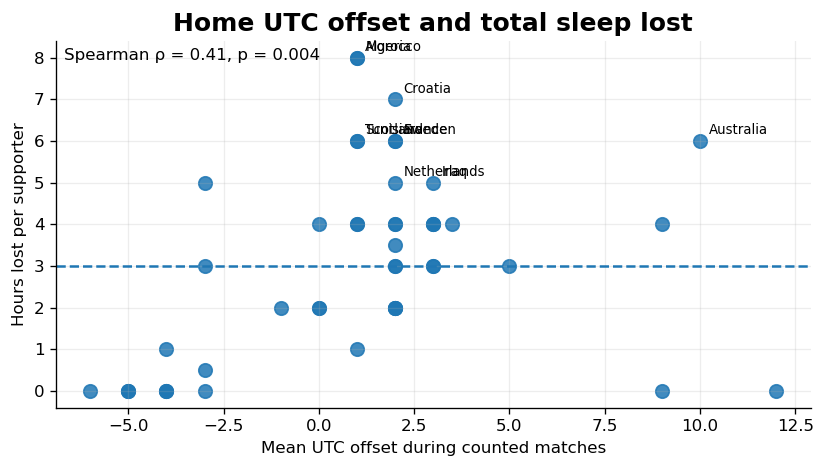

In [16]:
offset_summary = (
    rankings.groupby("fanbase", as_index=False)
    .agg(
        mean_utc_offset_hours=("mean_utc_offset_hours", "mean"),
        total_sleep_hours=("total_sleep_hours", "mean"),
    )
)

rho_offset, p_offset = spearmanr(
    offset_summary["mean_utc_offset_hours"],
    offset_summary["total_sleep_hours"],
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(
    offset_summary["mean_utc_offset_hours"],
    offset_summary["total_sleep_hours"],
    s=65,
    alpha=0.85,
)

for _, row in rankings.head(10).iterrows():
    ax.annotate(
        row["fanbase"],
        (row["mean_utc_offset_hours"], row["total_sleep_hours"]),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.axhline(rankings["total_sleep_hours"].median(), linestyle="--", linewidth=1.5)
ax.set_title("Home UTC offset and total sleep lost")
ax.set_xlabel("Mean UTC offset during counted matches")
ax.set_ylabel("Hours lost per supporter")
ax.text(
    0.01,
    0.98,
    f"Spearman ρ = {rho_offset:.2f}, p = {p_offset:.3f}",
    transform=ax.transAxes,
    va="top",
)
plt.tight_layout()
plt.show()


## Local kick-off timing and sleep severity


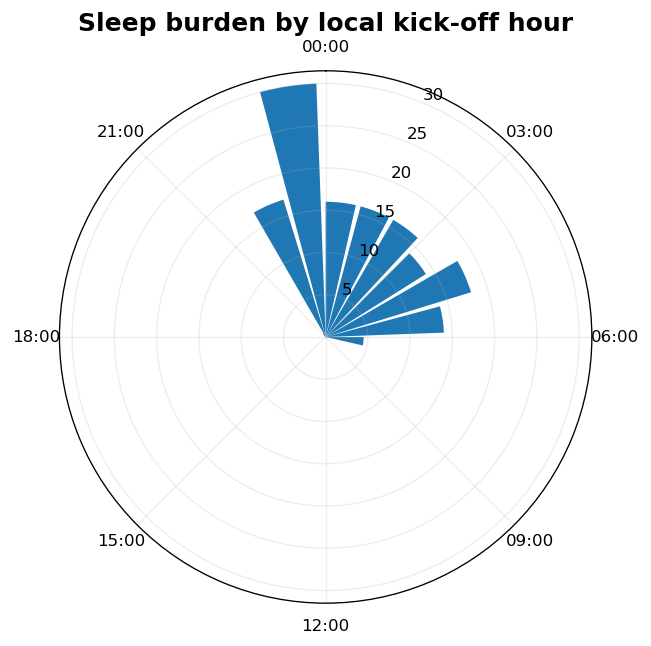

In [17]:
local_hour_summary = (
    team_matches.groupby("local_hour_int", as_index=False)
    .agg(
        fanbase_views=("match_number", "count"),
        affected_views=("sleep_affected", "sum"),
        total_sleep_hours=("sleep_overlap_hours", "sum"),
    )
    .sort_values("local_hour_int")
)

local_hour_summary["affected_rate"] = (
    local_hour_summary["affected_views"] / local_hour_summary["fanbase_views"]
)

full_hours = pd.DataFrame({"local_hour_int": np.arange(24)})
local_hour_summary = (
    full_hours.merge(local_hour_summary, on="local_hour_int", how="left")
    .fillna(0)
)

theta = 2 * np.pi * local_hour_summary["local_hour_int"] / 24
width = 2 * np.pi / 24 * 0.86

fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(111, projection="polar")
ax.bar(theta, local_hour_summary["total_sleep_hours"], width=width, align="edge")
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_xticks(2 * np.pi * np.arange(0, 24, 3) / 24)
ax.set_xticklabels([f"{hour:02d}:00" for hour in range(0, 24, 3)])
ax.set_title("Sleep burden by local kick-off hour", pad=24)
plt.tight_layout()
plt.show()


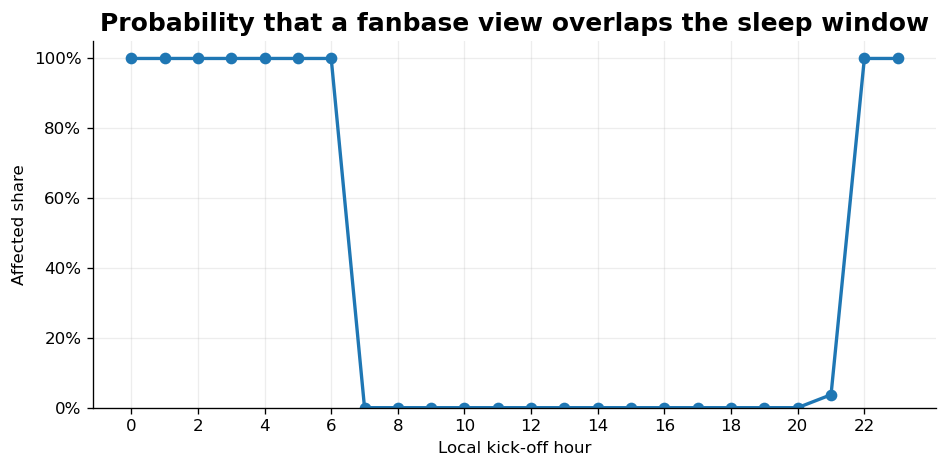

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    local_hour_summary["local_hour_int"],
    local_hour_summary["affected_rate"],
    marker="o",
    linewidth=2,
)
ax.set_title("Probability that a fanbase view overlaps the sleep window")
ax.set_xlabel("Local kick-off hour")
ax.set_ylabel("Affected share")
ax.set_xticks(np.arange(0, 24, 2))
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(PercentFormatter(1))
plt.tight_layout()
plt.show()


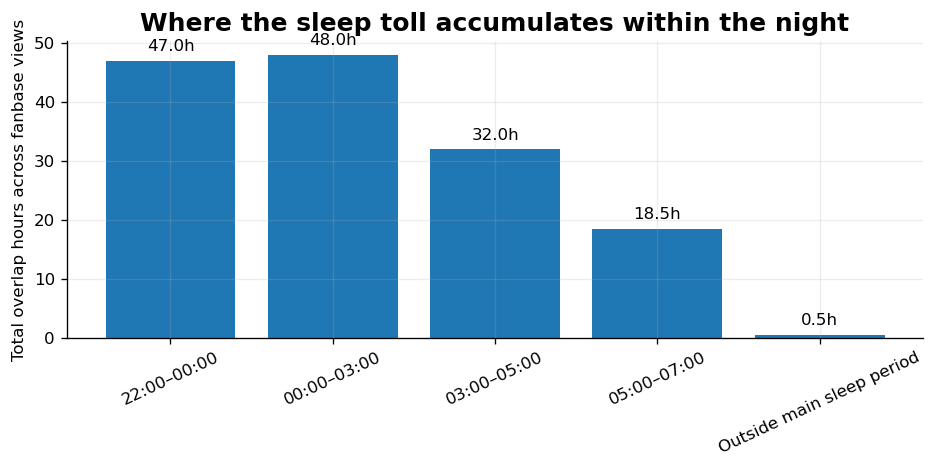

,time_band,fanbase_views,total_sleep_hours,mean_overlap
3,22:00–00:00,31,47.000,1.516
0,00:00–03:00,24,48.000,2.000
1,03:00–05:00,16,32.000,2.000
2,05:00–07:00,12,18.500,1.542
4,Outside main sleep period,97,0.500,0.005


In [19]:
def time_band(hour):
    if 22 <= hour < 24:
        return "22:00–00:00"
    if 0 <= hour < 3:
        return "00:00–03:00"
    if 3 <= hour < 5:
        return "03:00–05:00"
    if 5 <= hour < 7:
        return "05:00–07:00"
    return "Outside main sleep period"


band_order = [
    "22:00–00:00",
    "00:00–03:00",
    "03:00–05:00",
    "05:00–07:00",
    "Outside main sleep period",
]

time_band_summary = (
    team_matches.assign(time_band=team_matches["local_hour"].map(time_band))
    .groupby("time_band", as_index=False)
    .agg(
        fanbase_views=("match_number", "count"),
        total_sleep_hours=("sleep_overlap_hours", "sum"),
        mean_overlap=("sleep_overlap_hours", "mean"),
    )
)

time_band_summary["time_band"] = pd.Categorical(
    time_band_summary["time_band"],
    categories=band_order,
    ordered=True,
)
time_band_summary = time_band_summary.sort_values("time_band")

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    time_band_summary["time_band"].astype(str),
    time_band_summary["total_sleep_hours"],
)
ax.bar_label(bars, fmt="%.1fh", padding=4)
ax.set_title("Where the sleep toll accumulates within the night")
ax.set_xlabel("")
ax.set_ylabel("Total overlap hours across fanbase views")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

display(time_band_summary)


## Stage, match and venue contributions


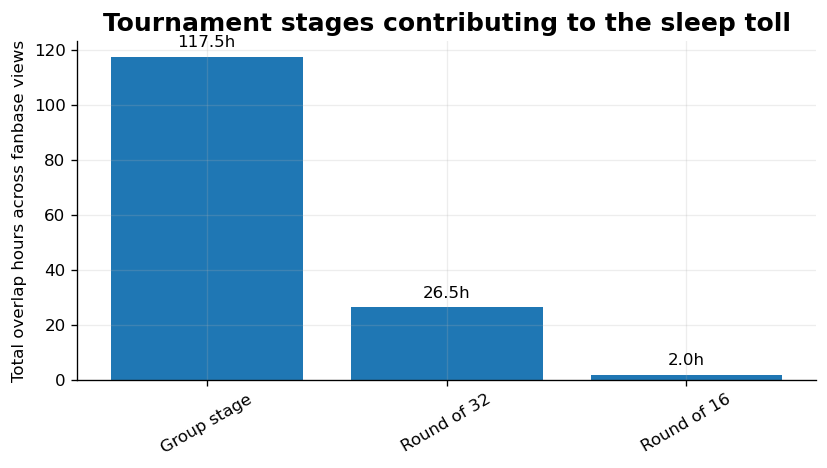

,stage,fanbase_views,affected_views,total_sleep_hours
0,Group stage,144,69,117.500
2,Round of 32,32,14,26.500
1,Round of 16,4,1,2.000


In [20]:
stage_sleep = (
    team_matches.groupby("stage", as_index=False)
    .agg(
        fanbase_views=("match_number", "count"),
        affected_views=("sleep_affected", "sum"),
        total_sleep_hours=("sleep_overlap_hours", "sum"),
    )
)

stage_sleep["stage"] = pd.Categorical(
    stage_sleep["stage"], categories=stage_order, ordered=True
)
stage_sleep = stage_sleep.sort_values("stage")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(stage_sleep["stage"].astype(str), stage_sleep["total_sleep_hours"])
ax.bar_label(bars, fmt="%.1fh", padding=4)
ax.set_title("Tournament stages contributing to the sleep toll")
ax.set_xlabel("")
ax.set_ylabel("Total overlap hours across fanbase views")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

display(stage_sleep)


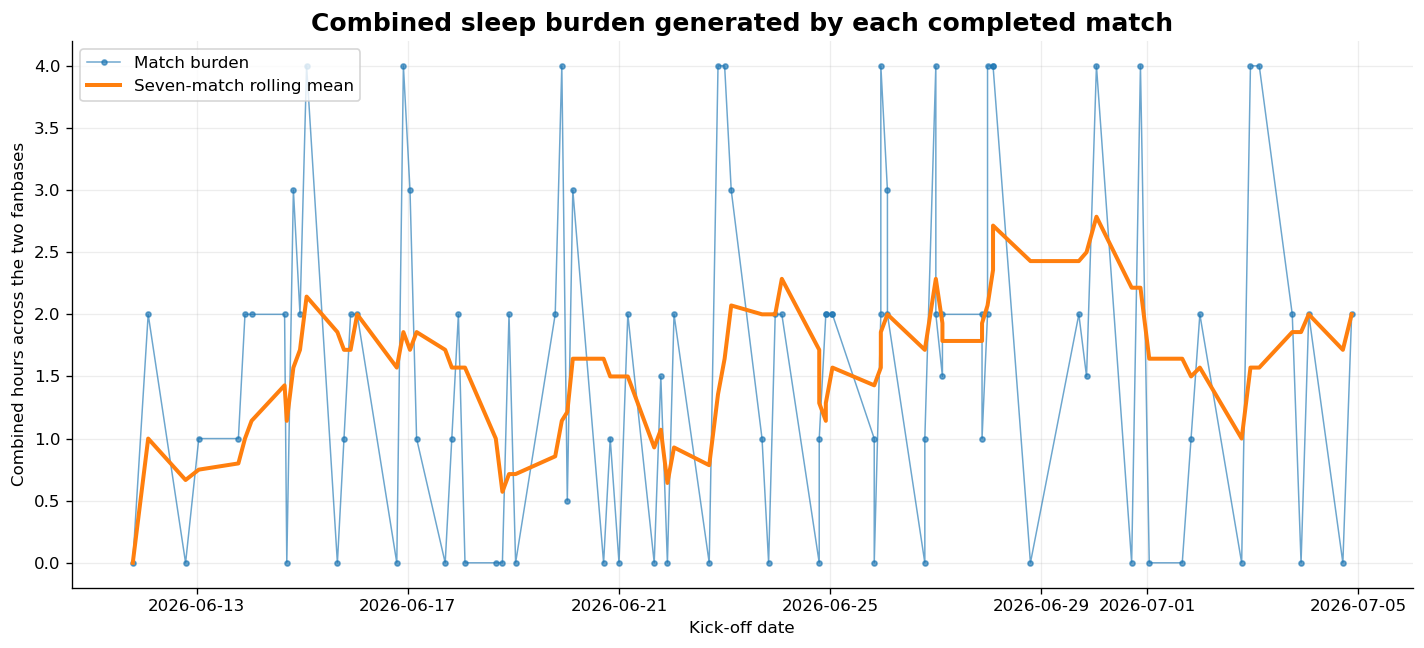

,match_number,matchup,kickoff_utc,stage,combined_sleep_hours,affected_fanbases,venue
11,12,Sweden v Tunisia,2026-06-15 02:00:00+00:00,Group stage,4.000,2,Estadio BBVA
17,18,Iraq v Norway,2026-06-16 22:00:00+00:00,Group stage,4.000,2,Gillette Stadium
29,30,Scotland v Morocco,2026-06-19 22:00:00+00:00,Group stage,4.000,2,Gillette Stadium
41,42,France v Iraq,2026-06-22 21:00:00+00:00,Group stage,4.000,2,Lincoln Financial Field
42,43,Norway v Senegal,2026-06-23 00:00:00+00:00,Group stage,4.000,2,MetLife Stadium
57,58,Tunisia v Netherlands,2026-06-25 23:00:00+00:00,Group stage,4.000,2,Arrowhead Stadium
62,63,Cape Verde v Saudi Arabia,2026-06-27 00:00:00+00:00,Group stage,4.000,2,NRG Stadium
69,70,DR Congo v Uzbekistan,2026-06-27 23:30:00+00:00,Group stage,4.000,2,Mercedes-Benz Stadium
70,71,Algeria v Austria,2026-06-28 02:00:00+00:00,Group stage,4.000,2,Arrowhead Stadium
71,72,Jordan v Argentina,2026-06-28 02:00:00+00:00,Group stage,4.000,2,AT&T Stadium


In [21]:
matchup_lookup = (
    completed.set_index("Match #")
    .apply(lambda row: f"{row['Team A']} v {row['Team B']}", axis=1)
)

match_burden = (
    team_matches.groupby(
        ["match_number", "kickoff_utc", "stage", "venue", "host_city"],
        as_index=False,
    )
    .agg(
        combined_sleep_hours=("sleep_overlap_hours", "sum"),
        affected_fanbases=("sleep_affected", "sum"),
    )
)
match_burden["matchup"] = match_burden["match_number"].map(matchup_lookup)
match_burden = match_burden.sort_values("kickoff_utc")
match_burden["rolling_7_match_mean"] = (
    match_burden["combined_sleep_hours"].rolling(7, min_periods=1).mean()
)

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(
    match_burden["kickoff_utc"],
    match_burden["combined_sleep_hours"],
    marker="o",
    markersize=3,
    linewidth=0.9,
    alpha=0.65,
    label="Match burden",
)
ax.plot(
    match_burden["kickoff_utc"],
    match_burden["rolling_7_match_mean"],
    linewidth=2.4,
    label="Seven-match rolling mean",
)
ax.set_title("Combined sleep burden generated by each completed match")
ax.set_xlabel("Kick-off date")
ax.set_ylabel("Combined hours across the two fanbases")
ax.legend()
plt.tight_layout()
plt.show()

top_matches = match_burden.sort_values(
    ["combined_sleep_hours", "affected_fanbases", "match_number"],
    ascending=[False, False, True],
).head(15)

display(
    top_matches[
        [
            "match_number",
            "matchup",
            "kickoff_utc",
            "stage",
            "combined_sleep_hours",
            "affected_fanbases",
            "venue",
        ]
    ]
)


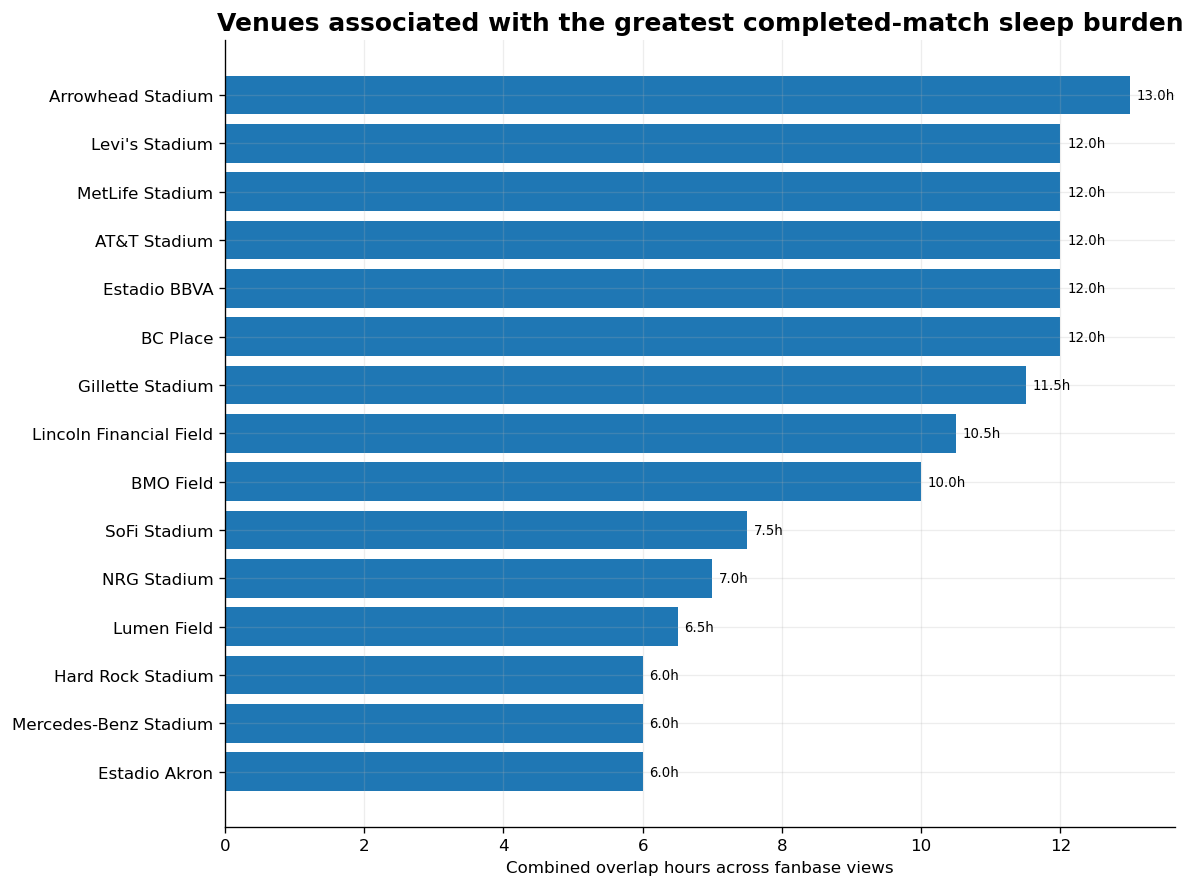

In [22]:
venue_sleep = (
    team_matches.groupby(
        ["host_country", "host_city", "venue"],
        as_index=False,
    )
    .agg(
        completed_matches=("match_number", "nunique"),
        combined_sleep_hours=("sleep_overlap_hours", "sum"),
        affected_fanbase_views=("sleep_affected", "sum"),
    )
    .sort_values("combined_sleep_hours", ascending=False)
)

top_venues = venue_sleep.head(15).sort_values("combined_sleep_hours")

fig, ax = plt.subplots(figsize=(10, 7.5))
bars = ax.barh(top_venues["venue"], top_venues["combined_sleep_hours"])
ax.bar_label(bars, fmt="%.1fh", padding=4, fontsize=8)
ax.set_title("Venues associated with the greatest completed-match sleep burden")
ax.set_xlabel("Combined overlap hours across fanbase views")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## How burden accumulated through the tournament


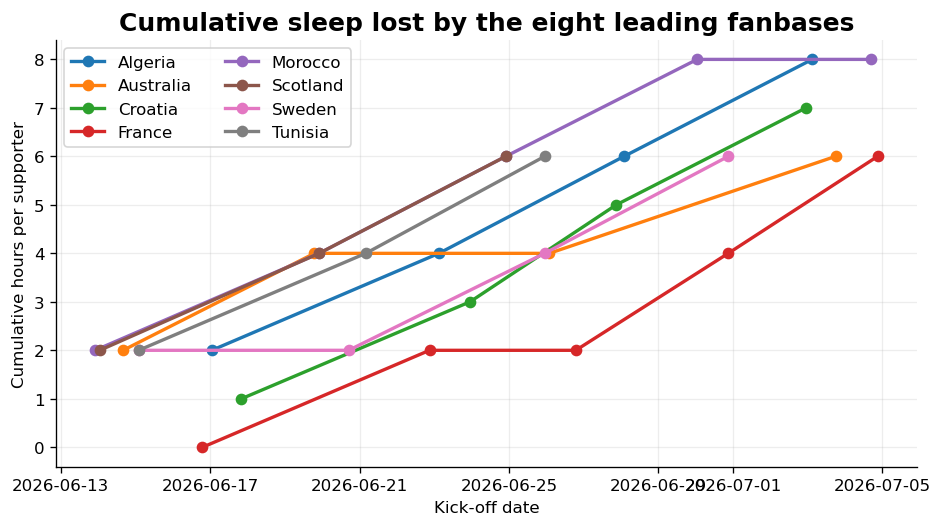

In [23]:
top_teams = rankings.head(8)["fanbase"].tolist()

cumulative_records = (
    team_matches[team_matches["fanbase"].isin(top_teams)]
    .sort_values(["fanbase", "kickoff_utc"])
    .copy()
)
cumulative_records["cumulative_sleep_hours"] = (
    cumulative_records.groupby("fanbase")["sleep_overlap_hours"].cumsum()
)

fig, ax = plt.subplots(figsize=(8, 4.5))
for fanbase, group in cumulative_records.groupby("fanbase"):
    ax.plot(
        group["kickoff_utc"],
        group["cumulative_sleep_hours"],
        marker="o",
        linewidth=2,
        label=fanbase,
    )

ax.set_title("Cumulative sleep lost by the eight leading fanbases")
ax.set_xlabel("Kick-off date")
ax.set_ylabel("Cumulative hours per supporter")
ax.legend(ncol=2)
plt.tight_layout()
plt.show()


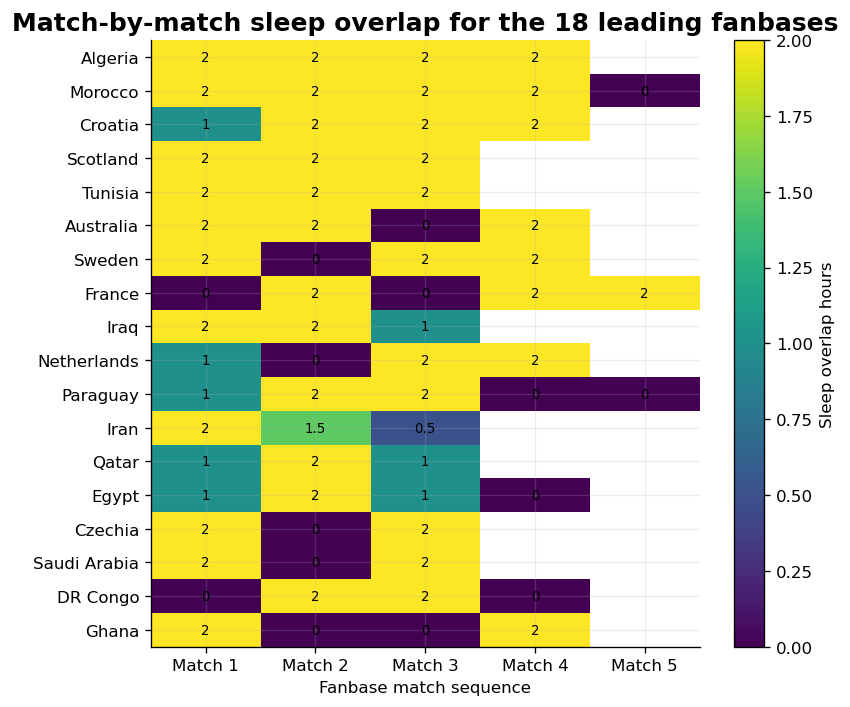

In [24]:
sequence_data = team_matches.copy()
sequence_data["match_sequence"] = (
    sequence_data.sort_values(["fanbase", "kickoff_utc"])
    .groupby("fanbase")
    .cumcount()
    + 1
)

heatmap_teams = rankings.head(18)["fanbase"].tolist()
heatmap_matrix = (
    sequence_data[sequence_data["fanbase"].isin(heatmap_teams)]
    .pivot(
        index="fanbase",
        columns="match_sequence",
        values="sleep_overlap_hours",
    )
    .reindex(heatmap_teams)
)

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(heatmap_matrix, aspect="auto")
ax.set_title("Match-by-match sleep overlap for the 18 leading fanbases")
ax.set_xlabel("Fanbase match sequence")
ax.set_ylabel("")
ax.set_xticks(np.arange(len(heatmap_matrix.columns)))
ax.set_xticklabels([f"Match {number}" for number in heatmap_matrix.columns])
ax.set_yticks(np.arange(len(heatmap_matrix.index)))
ax.set_yticklabels(heatmap_matrix.index)

for row_index in range(heatmap_matrix.shape[0]):
    for column_index in range(heatmap_matrix.shape[1]):
        value = heatmap_matrix.iloc[row_index, column_index]
        if pd.notna(value):
            ax.text(
                column_index,
                row_index,
                f"{value:g}",
                ha="center",
                va="center",
                fontsize=8,
            )

fig.colorbar(image, ax=ax, label="Sleep overlap hours")
plt.tight_layout()
plt.show()


## Inequality and concentration of the sleep burden


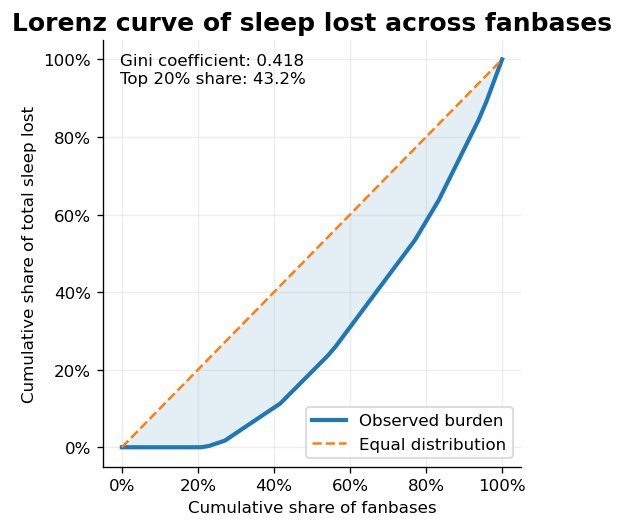

In [25]:
def gini_coefficient(values):
    array = np.sort(np.asarray(values, dtype=float))
    if len(array) == 0 or array.sum() == 0:
        return 0.0
    n = len(array)
    weighted_sum = np.sum(np.arange(1, n + 1) * array)
    return (2 * weighted_sum / (n * array.sum())) - (n + 1) / n


sorted_hours = np.sort(rankings["total_sleep_hours"].to_numpy())
cumulative_hours = np.insert(np.cumsum(sorted_hours), 0, 0)
cumulative_hours = cumulative_hours / cumulative_hours[-1]
population_share = np.linspace(0, 1, len(cumulative_hours))

gini = gini_coefficient(sorted_hours)
top_quintile_n = math.ceil(len(sorted_hours) * 0.2)
top_quintile_share = (
    np.sort(sorted_hours)[-top_quintile_n:].sum() / sorted_hours.sum()
)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.plot(population_share, cumulative_hours, linewidth=2.5, label="Observed burden")
ax.plot([0, 1], [0, 1], linestyle="--", label="Equal distribution")
ax.fill_between(population_share, cumulative_hours, population_share, alpha=0.12)
ax.set_title("Lorenz curve of sleep lost across fanbases")
ax.set_xlabel("Cumulative share of fanbases")
ax.set_ylabel("Cumulative share of total sleep lost")
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend()
ax.text(
    0.04,
    0.90,
    f"Gini coefficient: {gini:.3f}\nTop 20% share: {top_quintile_share:.1%}",
    transform=ax.transAxes,
)
plt.tight_layout()
plt.show()


## Sensitivity analysis across nine assumption sets

The baseline is tested against three sleep windows and three viewing durations. This fills the missing advanced-analysis section from the earlier notebook.


In [26]:
SCENARIOS = []

for sleep_start, sleep_end, window_label in [
    (time(22, 0), time(6, 0), "22:00–06:00"),
    (time(23, 0), time(7, 0), "23:00–07:00"),
    (time(0, 0), time(8, 0), "00:00–08:00"),
]:
    for duration in [90, 105, 120]:
        SCENARIOS.append({
            "scenario": f"{window_label} · {duration} min",
            "window": window_label,
            "duration": duration,
            "sleep_start": sleep_start,
            "sleep_end": sleep_end,
        })


def calculate_scenario_ranking(scenario):
    duration = scenario["duration"]
    eligible = schedule[
        (
            schedule["kickoff_utc"]
            + pd.Timedelta(minutes=duration)
        ).le(SNAPSHOT_UTC)
        & schedule["Team A"].ne("TBD")
        & schedule["Team B"].ne("TBD")
    ]

    scenario_rows = []

    for _, match in eligible.iterrows():
        for fanbase in (match["Team A"], match["Team B"]):
            zone_name = TEAM_TIMEZONES[fanbase][0]
            local_start = match["kickoff_utc"].tz_convert(
                ZoneInfo(zone_name)
            )
            scenario_rows.append({
                "fanbase": fanbase,
                "sleep_hours": sleep_overlap_hours(
                    local_start,
                    sleep_start=scenario["sleep_start"],
                    sleep_end=scenario["sleep_end"],
                    match_minutes=duration,
                ),
            })

    ranking = (
        pd.DataFrame(scenario_rows)
        .groupby("fanbase", as_index=False)
        .agg(sleep_hours=("sleep_hours", "sum"))
    )

    ranking = (
        team_metadata[["fanbase"]]
        .merge(ranking, on="fanbase", how="left")
        .fillna({"sleep_hours": 0})
    )

    ranking["rank"] = (
        ranking["sleep_hours"]
        .rank(method="min", ascending=False)
        .astype(int)
    )
    ranking["scenario"] = scenario["scenario"]
    ranking["window"] = scenario["window"]
    ranking["duration"] = scenario["duration"]

    return ranking


sensitivity_results = pd.concat(
    [calculate_scenario_ranking(scenario) for scenario in SCENARIOS],
    ignore_index=True,
)

scenario_maximum = (
    sensitivity_results.groupby("scenario")["sleep_hours"]
    .transform("max")
)
sensitivity_winners = (
    sensitivity_results[
        sensitivity_results["sleep_hours"].eq(scenario_maximum)
    ][["scenario", "window", "duration", "fanbase", "sleep_hours"]]
    .sort_values(["window", "duration", "fanbase"])
    .reset_index(drop=True)
)

ranking_robustness = (
    sensitivity_results.groupby("fanbase", as_index=False)
    .agg(
        mean_rank=("rank", "mean"),
        best_rank=("rank", "min"),
        worst_rank=("rank", "max"),
        rank_sd=("rank", "std"),
        first_place_scenarios=("rank", lambda values: int((values == 1).sum())),
        mean_sleep_hours=("sleep_hours", "mean"),
        min_sleep_hours=("sleep_hours", "min"),
        max_sleep_hours=("sleep_hours", "max"),
    )
    .sort_values(["mean_rank", "fanbase"])
)

display(sensitivity_winners)
display(ranking_robustness.head(20))


,scenario,window,duration,fanbase,sleep_hours
0,00:00–08:00 · 90 min,00:00–08:00,90,Algeria,6.000
1,00:00–08:00 · 105 min,00:00–08:00,105,Algeria,7.000
2,00:00–08:00 · 120 min,00:00–08:00,120,Algeria,8.000
3,22:00–06:00 · 90 min,22:00–06:00,90,Algeria,6.000
4,22:00–06:00 · 90 min,22:00–06:00,90,Croatia,6.000
5,22:00–06:00 · 90 min,22:00–06:00,90,Morocco,6.000
6,22:00–06:00 · 105 min,22:00–06:00,105,Algeria,7.000
7,22:00–06:00 · 105 min,22:00–06:00,105,Croatia,7.000
8,22:00–06:00 · 105 min,22:00–06:00,105,Morocco,7.000
9,22:00–06:00 · 120 min,22:00–06:00,120,Algeria,8.000


,fanbase,mean_rank,best_rank,worst_rank,rank_sd,first_place_scenarios,mean_sleep_hours,min_sleep_hours,max_sleep_hours
0,Algeria,1.000,1,1,0.000,9,7.000,6.000,8.000
27,Morocco,2.667,1,7,2.646,6,6.000,3.000,8.000
10,Croatia,2.889,1,5,1.616,3,5.750,3.500,8.000
41,Sweden,4.556,4,5,0.527,0,4.917,3.500,6.000
2,Australia,6.000,2,12,4.583,0,5.000,4.000,6.000
43,Tunisia,6.000,2,12,4.583,0,5.000,4.000,6.000
22,Iraq,7.222,5,9,1.787,0,4.333,3.000,6.000
28,Netherlands,7.222,5,9,1.787,0,4.333,3.000,6.000
36,Scotland,8.333,4,20,6.727,0,4.583,2.500,6.000
17,France,10.000,1,24,9.836,1,4.750,1.500,8.000


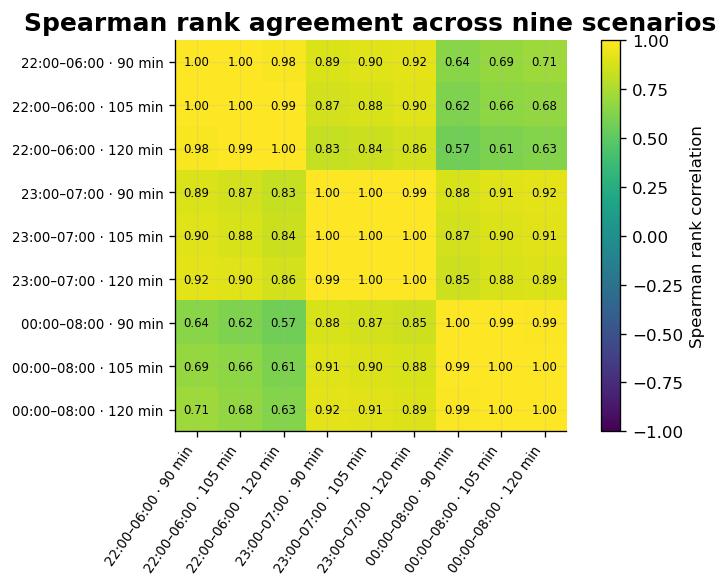

In [27]:
rank_matrix = (
    sensitivity_results.pivot(
        index="fanbase",
        columns="scenario",
        values="rank",
    )
)

scenario_labels = [scenario["scenario"] for scenario in SCENARIOS]
rank_matrix = rank_matrix[scenario_labels]
rank_correlation = rank_matrix.corr(method="spearman")

fig, ax = plt.subplots(figsize=(7, 5))
image = ax.imshow(rank_correlation, vmin=-1, vmax=1)
ax.set_title("Spearman rank agreement across nine scenarios")
ax.set_xticks(np.arange(len(scenario_labels)))
ax.set_yticks(np.arange(len(scenario_labels)))
ax.set_xticklabels(scenario_labels, rotation=55, ha="right", fontsize=8)
ax.set_yticklabels(scenario_labels, fontsize=8)

for row_index in range(len(scenario_labels)):
    for column_index in range(len(scenario_labels)):
        ax.text(
            column_index,
            row_index,
            f"{rank_correlation.iloc[row_index, column_index]:.2f}",
            ha="center",
            va="center",
            fontsize=7,
        )

fig.colorbar(image, ax=ax, label="Spearman rank correlation")
plt.tight_layout()
plt.show()


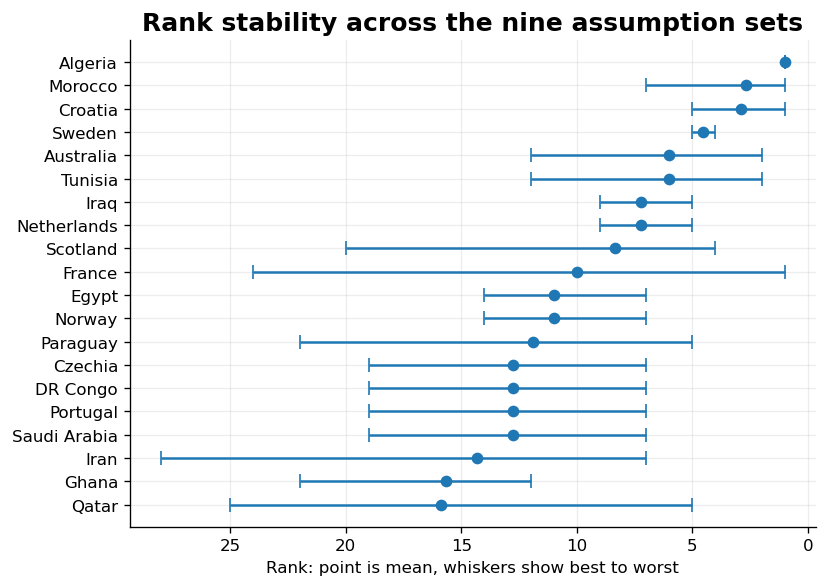

In [28]:
robust_plot = ranking_robustness.head(20).sort_values("mean_rank", ascending=False)

lower_error = robust_plot["mean_rank"] - robust_plot["best_rank"]
upper_error = robust_plot["worst_rank"] - robust_plot["mean_rank"]

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(
    robust_plot["mean_rank"],
    robust_plot["fanbase"],
    xerr=[lower_error, upper_error],
    fmt="o",
    capsize=4,
)
ax.set_title("Rank stability across the nine assumption sets")
ax.set_xlabel("Rank: point is mean, whiskers show best to worst")
ax.set_ylabel("")
ax.invert_xaxis()
plt.tight_layout()
plt.show()


## Unsupervised fanbase profiles

K-means is applied to five standardised burden features. The number of clusters is selected from 2–6 using silhouette score.


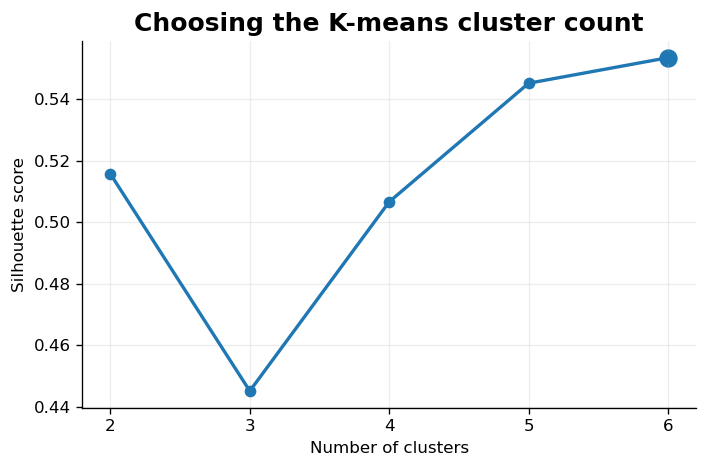

,k,silhouette_score
0,2,0.516
1,3,0.445
2,4,0.507
3,5,0.545
4,6,0.554


Selected k: 6


In [29]:
cluster_features = [
    "total_sleep_hours",
    "sleep_affected_share",
    "mean_sleep_hours_per_match",
    "max_single_match_sleep_hours",
    "matches_counted",
]

feature_frame = rankings.set_index("fanbase")[cluster_features]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(feature_frame)

cluster_model_scores = []

for k in range(2, 7):
    model = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=150)
    labels = model.fit_predict(scaled_features)
    cluster_model_scores.append({
        "k": k,
        "silhouette_score": silhouette_score(scaled_features, labels),
    })

cluster_model_scores = pd.DataFrame(cluster_model_scores)
best_k = int(
    cluster_model_scores.loc[
        cluster_model_scores["silhouette_score"].idxmax(),
        "k",
    ]
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(
    cluster_model_scores["k"],
    cluster_model_scores["silhouette_score"],
    marker="o",
    linewidth=2,
)
ax.scatter(
    [best_k],
    [
        cluster_model_scores.loc[
            cluster_model_scores["k"].eq(best_k),
            "silhouette_score",
        ].iloc[0]
    ],
    s=100,
)
ax.set_title("Choosing the K-means cluster count")
ax.set_xlabel("Number of clusters")
ax.set_ylabel("Silhouette score")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

display(cluster_model_scores)
print("Selected k:", best_k)


In [30]:
best_model = KMeans(n_clusters=best_k, random_state=42, n_init=10, max_iter=150)
raw_cluster_labels = best_model.fit_predict(scaled_features)

clustered_rankings = rankings.copy()
clustered_rankings["raw_cluster"] = raw_cluster_labels

raw_profile = (
    clustered_rankings.groupby("raw_cluster", as_index=False)
    .agg(
        fanbases=("fanbase", "count"),
        mean_total_sleep_hours=("total_sleep_hours", "mean"),
    )
    .sort_values("mean_total_sleep_hours")
)

cluster_name_map = {
    raw_cluster: f"Cluster {position + 1}"
    for position, raw_cluster in enumerate(raw_profile["raw_cluster"])
}

clustered_rankings["cluster"] = (
    clustered_rankings["raw_cluster"].map(cluster_name_map)
)

cluster_profiles = (
    clustered_rankings.groupby("cluster", as_index=False)
    .agg(
        fanbases=("fanbase", "count"),
        mean_total_sleep_hours=("total_sleep_hours", "mean"),
        mean_affected_share=("sleep_affected_share", "mean"),
        mean_per_match=("mean_sleep_hours_per_match", "mean"),
        mean_max_single_match=("max_single_match_sleep_hours", "mean"),
        mean_matches_counted=("matches_counted", "mean"),
    )
    .sort_values("mean_total_sleep_hours")
)

display(cluster_profiles)

cluster_members = (
    clustered_rankings.groupby("cluster")["fanbase"]
    .apply(lambda values: ", ".join(sorted(values)))
    .rename("fanbases")
    .reset_index()
)
display(cluster_members)


,cluster,fanbases,mean_total_sleep_hours,mean_affected_share,mean_per_match,mean_max_single_match,mean_matches_counted
0,Cluster 1,6,0.000,0.000,0.000,0.000,3.000
1,Cluster 2,5,0.100,0.050,0.025,0.100,4.200
2,Cluster 3,9,1.778,0.250,0.444,1.778,4.000
3,Cluster 4,11,3.773,0.568,0.943,1.955,4.000
4,Cluster 5,10,4.200,0.833,1.400,2.000,3.000
5,Cluster 6,7,6.571,0.786,1.507,2.000,4.429


,cluster,fanbases
0,Cluster 1,"Curaçao, Haiti, New Zealand, Panama, South Kor..."
1,Cluster 2,"Brazil, Canada, Colombia, Ecuador, Mexico"
2,Cluster 3,"Bosnia & Herzegovina, Cape Verde, England, Ivo..."
3,Cluster 4,"Argentina, Austria, Belgium, DR Congo, Egypt, ..."
4,Cluster 5,"Czechia, Iran, Iraq, Jordan, Qatar, Saudi Arab..."
5,Cluster 6,"Algeria, Australia, Croatia, France, Morocco, ..."


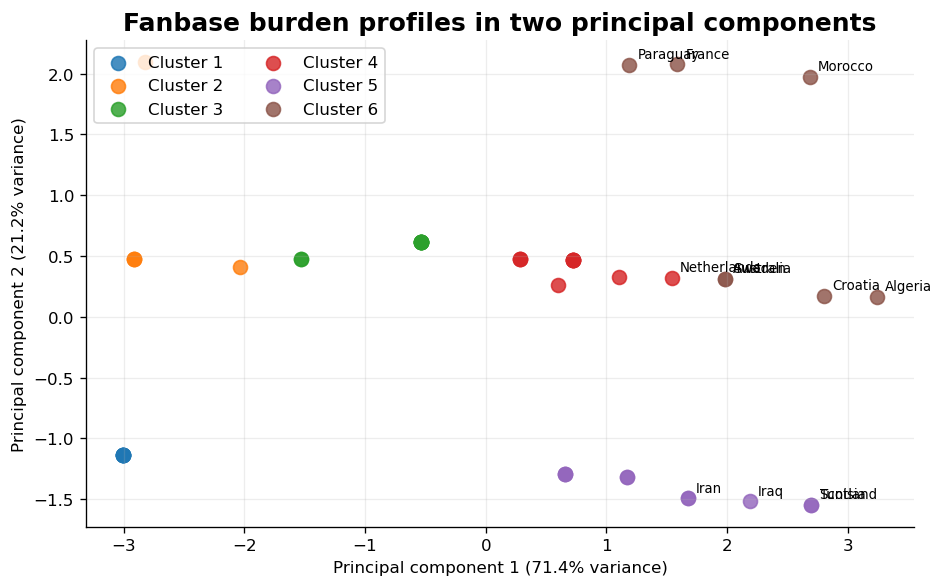

In [31]:
pca = PCA(n_components=2)
pca_coordinates = pca.fit_transform(scaled_features)

clustered_rankings["pca_1"] = pca_coordinates[:, 0]
clustered_rankings["pca_2"] = pca_coordinates[:, 1]

fig, ax = plt.subplots(figsize=(8, 5))

for cluster, group in clustered_rankings.groupby("cluster"):
    ax.scatter(
        group["pca_1"],
        group["pca_2"],
        s=70,
        alpha=0.82,
        label=cluster,
    )

for _, row in clustered_rankings.nsmallest(12, "rank").iterrows():
    ax.annotate(
        row["fanbase"],
        (row["pca_1"], row["pca_2"]),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("Fanbase burden profiles in two principal components")
ax.set_xlabel(
    f"Principal component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)"
)
ax.set_ylabel(
    f"Principal component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)"
)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()


## Relationships among burden metrics


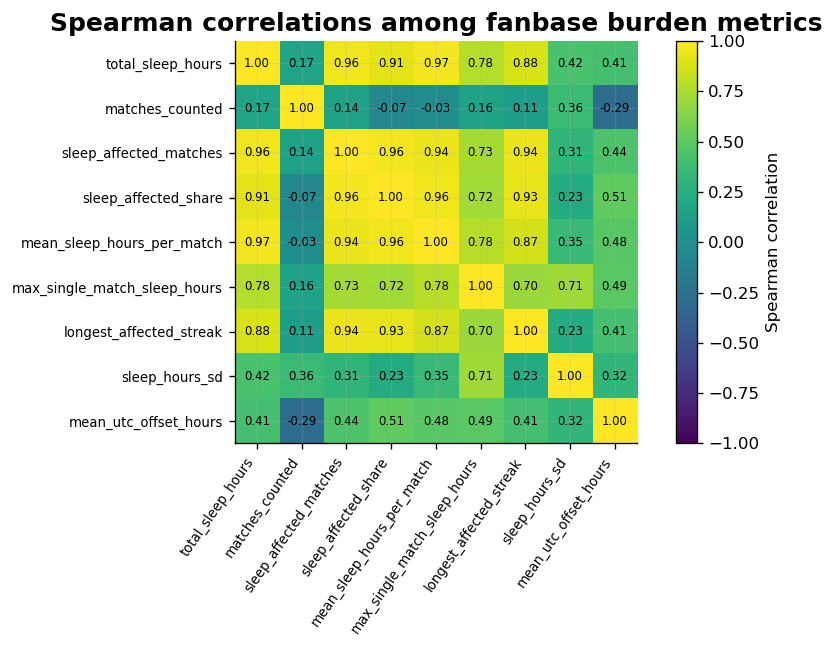

In [32]:
correlation_features = [
    "total_sleep_hours",
    "matches_counted",
    "sleep_affected_matches",
    "sleep_affected_share",
    "mean_sleep_hours_per_match",
    "max_single_match_sleep_hours",
    "longest_affected_streak",
    "sleep_hours_sd",
    "mean_utc_offset_hours",
]

correlation_matrix = rankings[correlation_features].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 5.5))
image = ax.imshow(correlation_matrix, vmin=-1, vmax=1)
ax.set_title("Spearman correlations among fanbase burden metrics")
ax.set_xticks(np.arange(len(correlation_features)))
ax.set_yticks(np.arange(len(correlation_features)))
ax.set_xticklabels(correlation_features, rotation=55, ha="right", fontsize=8)
ax.set_yticklabels(correlation_features, fontsize=8)

for row_index in range(len(correlation_features)):
    for column_index in range(len(correlation_features)):
        ax.text(
            column_index,
            row_index,
            f"{correlation_matrix.iloc[row_index, column_index]:.2f}",
            ha="center",
            va="center",
            fontsize=7,
        )

fig.colorbar(image, ax=ax, label="Spearman correlation")
plt.tight_layout()
plt.show()


In [33]:
correlation_rows = []

for feature in correlation_features[1:]:
    rho, p_value = spearmanr(
        rankings["total_sleep_hours"],
        rankings[feature],
    )
    correlation_rows.append({
        "feature": feature,
        "spearman_rho_with_total_sleep": rho,
        "p_value": p_value,
    })

correlations_with_total = (
    pd.DataFrame(correlation_rows)
    .sort_values(
        "spearman_rho_with_total_sleep",
        key=lambda values: values.abs(),
        ascending=False,
    )
)

display(correlations_with_total)


,feature,spearman_rho_with_total_sleep,p_value
3,mean_sleep_hours_per_match,0.968,0.000
1,sleep_affected_matches,0.960,0.000
2,sleep_affected_share,0.915,0.000
5,longest_affected_streak,0.878,0.000
4,max_single_match_sleep_hours,0.776,0.000
6,sleep_hours_sd,0.423,0.003
7,mean_utc_offset_hours,0.410,0.004
0,matches_counted,0.167,0.256


## Final combined findings


In [34]:
baseline_with_robustness = (
    rankings.merge(ranking_robustness, on="fanbase", how="left")
    .sort_values("rank")
)

most_robust = ranking_robustness.sort_values(
    ["rank_sd", "mean_rank", "fanbase"]
).iloc[0]

largest_venue = venue_sleep.iloc[0]
most_costly_match = top_matches.iloc[0]
average_scenario_correlation = (
    rank_correlation.where(
        ~np.eye(len(rank_correlation), dtype=bool)
    )
    .stack()
    .mean()
)

display(Markdown(f'''
### Main findings

1. **{top_fanbase["fanbase"]} leads the baseline ranking** at **{top_fanbase["total_sleep_hours"]:.1f} hours per supporter**. The standardised collective interpretation is **{top_fanbase["years_per_million_supporters"]:,.0f} years per one million supporters**.
2. Across all 48 fanbases, the model records **{rankings["total_sleep_hours"].sum():.1f} supporter-hours per representative fan**, with a mean of **{rankings["total_sleep_hours"].mean():.2f} hours**.
3. The burden is uneven: the **Gini coefficient is {gini:.3f}**, and the top fifth of fanbases account for **{top_quintile_share:.1%}** of all modelled sleep loss.
4. **{largest_venue["venue"]}** is associated with the highest completed-match venue burden at **{largest_venue["combined_sleep_hours"]:.1f} combined hours** across fanbase views.
5. One of the most sleep-costly completed fixtures is **{most_costly_match["matchup"]}**, with **{most_costly_match["combined_sleep_hours"]:.1f} combined hours** across its two fanbases.
6. The scenario rankings are highly consistent overall: the mean pairwise Spearman agreement is **{average_scenario_correlation:.3f}**.
7. **{most_robust["fanbase"]}** has the smallest rank variation across the nine scenarios, with a mean rank of **{most_robust["mean_rank"]:.2f}** and a best-to-worst range of **{int(most_robust["best_rank"])}-{int(most_robust["worst_rank"])}**.
8. The K-means screening selected **{best_k} clusters** among the tested values of 2-6.
'''))

display(
    baseline_with_robustness[
        [
            "rank",
            "fanbase",
            "total_sleep_hours",
            "sleep_affected_share",
            "mean_rank",
            "best_rank",
            "worst_rank",
            "first_place_scenarios",
        ]
    ].head(20)
)



### Main findings

1. **Algeria leads the baseline ranking** at **8.0 hours per supporter**. The standardised collective interpretation is **913 years per one million supporters**.
2. Across all 48 fanbases, the model records **146.0 supporter-hours per representative fan**, with a mean of **3.04 hours**.
3. The burden is uneven: the **Gini coefficient is 0.418**, and the top fifth of fanbases account for **43.2%** of all modelled sleep loss.
4. **Arrowhead Stadium** is associated with the highest completed-match venue burden at **13.0 combined hours** across fanbase views.
5. One of the most sleep-costly completed fixtures is **Sweden v Tunisia**, with **4.0 combined hours** across its two fanbases.
6. The scenario rankings are highly consistent overall: the mean pairwise Spearman agreement is **0.850**.
7. **Algeria** has the smallest rank variation across the nine scenarios, with a mean rank of **1.00** and a best-to-worst range of **1-1**.
8. The K-means screening selected **6 clusters** among the tested values of 2-6.


,rank,fanbase,total_sleep_hours,sleep_affected_share,mean_rank,best_rank,worst_rank,first_place_scenarios
0,1,Algeria,8.000,1.000,1.000,1,1,9
1,2,Morocco,8.000,0.800,2.667,1,7,6
2,3,Croatia,7.000,1.000,2.889,1,5,3
3,4,Scotland,6.000,1.000,8.333,4,20,0
4,5,Tunisia,6.000,1.000,6.000,2,12,0
5,6,Australia,6.000,0.750,6.000,2,12,0
6,7,Sweden,6.000,0.750,4.556,4,5,0
7,8,France,6.000,0.600,10.000,1,24,1
8,9,Iraq,5.000,1.000,7.222,5,9,0
9,10,Netherlands,5.000,0.750,7.222,5,9,0


## Interpretation limits

- The sleep window is a modelling assumption, not an observed bedtime for every supporter.
- Each country or fanbase is represented by one home time zone and one city.
- The model assumes a supporter watches the full viewing window from kick-off.
- Population and audience size are not measured here. The per-million figure is a standardised interpretation.
- Knockout participants are resolved only where known at the fixed snapshot.
- The schedule is fixed, so statistical tests describe patterns in this tournament dataset rather than a random sample of future tournaments.
- Match outcomes, broadcast reach, extra time, penalties and individual viewing behaviour are outside this model.
